In [2]:
!pip install -U classiq
!pip install keyrings.alt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.1/657.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.25.0
    Uninstalling zstandard-0.25.0:
      Successfully uninstalled zstandard-0.25.0
  Attempting uninstall: pyomo
    Found existing installation: pyomo 6.10.0
    Uninstalling pyomo-6.10.0:
      Successfully 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from classiq import *

In [6]:
import classiq
classiq.authenticate(overwrite=True)

If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DRPWJ-PTQV&scope=offline_access
Your user code: RPWJ-PTQV


In [8]:
# import modules
from classiq import *
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc

import os

# custom module
# from fifth_harmony import *

# Solving Linear Differential Equations

<img src="imgs/trackC-banner.jpg">

**Team name:** The Fifth Harmony Bloch Busters.

**Team members:** Hari, Julia, Prakriti, Rodrigo and Yiwen.

The present Jupyter notebook is a modification of [Classiq's implementation](https://github.com/Classiq/classiq-library/blob/main/community/paper_implementation_project/quantum_algo_for_solving_linear_differential_equations/harmonic_oscillator.ipynb) of the paper [A Quantum Algorithm for Solving Linear Differential Equations: Theory and Experiment (arXiv:1807.04553)](https://arxiv.org/pdf/1807.04553).

## Goals

- A quantum program that solves the harmonic oscillator equation using the algorithm from the paper
- Computed kinetic and potential energy values as functions of time, derived from the simulated output
- An investigation of how parameter choices (e.g., amplitude bounds in state preparation) affect energy estimations
- A graphical analysis of circuit depth and width under different optimization settings

## Solving the differential equation of the harmonic oscillator:

$$ \ddot{y} + \omega^2 y = b_1, \quad y(t_0) = y_0, \quad \dot{y}(t_0) = \dot{y}_0 \,. $$

Note that the above system's particular solution is $y_p = b_1 / \omega^2$. Moreover, this equation can be rewritten as a first-order system:

$$\frac{d\vec{x}}{dt} = \begin{bmatrix}
0 & 1 \\
-\omega^2 & 0
\end{bmatrix} \vec{x} + \vec{b} \,;
\qquad
\vec{x}(t) = \begin{bmatrix}
y \\ \dot{y}
\end{bmatrix} \,,
\qquad
\vec{b}(t) = \begin{bmatrix}
b_0 \\ b_1
\end{bmatrix}
. $$

By defining the shifted variable $z(t) = y(t) - (b_1 / \omega^2)$ then $z(t)$ satisfies the homogeneous equation

$$ \ddot{z} + \omega^2 z = 0 \,.$$

This last equation leads to the general solution of

$$ y(t) = B \cos(\omega(t-t_0)) + C \sin(\omega (t-t_0)) + \frac{b_1}{\omega^2} \,,$$

$$ \dot{y}(t) = \omega \, C \cos(\omega (t-t_0)) - \omega \, B \sin(\omega(t-t_0)) \,,$$

where $B = y_0 - (b_1 / \omega^2)$ and $C = (\dot{y}_0 + b_0)/\omega$.

The **kinetic** and **potential** energies are

$$ \mathrm{KE} = \frac{1}{2} \dot{y}^2 \qquad \text{and} \qquad \mathrm{PE} = \frac{1}{2} \omega^2 \left( y - \frac{b_1}{\omega^2} \right)^2 \,, $$

respectively.

In [54]:
# Inputs
n = 2  # dimension of vectors x(0) and b
#m = 3
k = 6 # order of the Taylor expansion
omega = 1 # frecuency

M = np.array([[0, 1], [-omega**2, 0]])

t0 = 0 # initial time

y0 = 1.0 # initial position
vy0 = 1.0 # initial velocity
x0 = np.array([y0, vy0]) # initial vector (pos, vel)

# shift to (velocity, equilibrium position)
b0 = 0.0
b1 = 0.0
b = np.array([b0, b1])

# Norms (used in coefficients)
x0_norm = np.linalg.norm(x0)
b_norm = np.linalg.norm(b)

# Note that quantum states |x0> = x0/||x0|| and |b> = b/||b|| are computed at 'encoding'

# Matrices
M_norm = np.linalg.norm(M,2)
A = M/np.linalg.norm(M,2)

# Constants
B = y0 - (b1 / omega**2)
C = (vy0 + b0) / omega


T   = k.bit_length()          # qubits for ancilla register
ancilla_dim = 2 ** T
dim = int(np.log2(n))

In [55]:
def pad_to_power_of_two(mat, target_size):
    n = mat.shape[0]
    if n == target_size:
        return mat
    result = np.eye(target_size, dtype=complex)
    result[:n, :n] = mat
    return result

In [56]:
vs1 = []
c = 0


def VS1(t):
    global vs1
    global c

    # --- Coefficient C_m, eq. (3) ---
    c = 0
    c_m: np.array = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        # C_m[i] = (x0_norm * (pow(t, i))) / m_factorial
        c_m[i] = (x0_norm * pow(t * M_norm, i)) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1

    c = np.sqrt(c) # C = sqrt(sum C_m)

    # --- Equation (5) ---
    if t == 0:
        vs1 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = (np.sqrt(c_m) / c) - e
    vs1 = np.identity(k + 1) - np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))

In [57]:
vs2 = []
d = 0


def VS2(t):
    global vs2
    global d

    # --- Coefficient D_m, eq. (3) ---
    d = 0
    d_n: np.array = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        # d_n[i - 1] = (b_norm * (pow(M_norm * t, i - 1))) / n_factorial
        d_n[i - 1] = (b_norm * (pow(M_norm * t, i - 1)) * t) / n_factorial
        d += d_n[i - 1]
        n_factorial *= i + 1

    d_n[k] = 0 # eq. (5)
    d = np.sqrt(d)  # D = sqrt(sum D_n)

    # --- Equation (5) ---
    if d == 0:
        vs2 = np.eye(k + 1, k + 1)
        return

    # Construct Unitary matrix with the first column as defined above in the markdown
    e = np.zeros(k + 1)
    e[0] = 1
    w = (np.sqrt(d_n) / d) - e
    vs2 = np.identity(k + 1) - np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))

In [58]:
v = []
N = 0


def V():
    global v
    global N
    v = []
    N = np.sqrt(c * c + d * d) # fancy N in the paper (see eq3)
    if N == 0:
        v = np.eye(2, 2)
    else:
        v.append([c / N, d / N])
        v.append([d / N, -c / N])
        v = np.array(v)

In [59]:
@qfunc
def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
    prob_00 = [i / x0_norm for i in x0]
    prob_b  = [i / b_norm for i in b] if b_norm > 0 else [0.0] * len(b)

    # inplace_prepare_amplitudes(prob_00, 0.01, x)

    VS1(t)
    VS2(t)
    V()

    unitary(v, y)

    #added padding

    vs1_p = pad_to_power_of_two(vs1, ancilla_dim)
    vs2_p = pad_to_power_of_two(vs2, ancilla_dim)
    control(
        y == 0,
        lambda: (inplace_prepare_amplitudes(prob_00, 0.01, x), unitary(vs1_p, ancilla)),
        lambda: (inplace_prepare_amplitudes(prob_b,  0.01, x), unitary(vs2_p, ancilla))
    )

    #control(
    #    y == 0,
    #    lambda: (inplace_prepare_amplitudes(prob_00, 0.01, x), unitary(vs1, ancilla)),
    #    lambda: (inplace_prepare_amplitudes(prob_b,  0.01, x), unitary(vs2, ancilla))
    #)

In [60]:
@qfunc
def evolution(x: QNum, ancilla: QNum):
    u_m = np.array([[1, 0], [0, 1]])

    for i in range(k + 1):
        U = u_m.copy()
        control(ancilla == i, lambda U=U: unitary(U, x))
        u_m = u_m @ A

In [61]:
@qfunc
def decoding(ancilla: QNum, y: QBit):
    #ws1 = vs1.conj().T
    #ws2 = vs2.conj().T
    #padded decoding
    ws1 = pad_to_power_of_two(vs1, ancilla_dim).conj().T
    ws2 = pad_to_power_of_two(vs2, ancilla_dim).conj().T
    w = v.conj().T
    control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
    unitary(w, y)

In [62]:
#T = int(np.log2(k + 1))  # no of ancilla qubits
#dim = int(np.log2(n))  # no of work qubits


def create_main_for_t(t: float):
    @qfunc
    def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
        # ancilla: Output[QNum[T]] -> log2(k+1)
        allocate(x)
        allocate(ancilla)
        allocate(y)

        encoding(x, ancilla, y, t)
        evolution(x, ancilla)
        decoding(ancilla, y)

    return main

In [63]:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### Measurement

In [64]:
y = [] # y(t)
y_dash = [] # y'(t)

t_initial = 0 # initial time
t_final = 1 # final time
t_step = 11 # number of steps to divide [t_initial, t_final]
time_range = np.linspace(t_initial, t_final, t_step)

for i, t in enumerate(time_range):
    print(f"Time = {t} --- case {i+1}/{t_step}")
    qmod = create_model(create_main_for_t(t))
    qmod = set_execution_preferences(qmod, execution_preferences)
    qprog = synthesize(qmod)
    job = execute(qprog)
    results = job.result_value()
    for j in results.parsed_state_vector:
        if int(j.bitstring[:-dim], 2) == 0:
            print(j.bitstring, " : ", np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 0:
                y.append(np.linalg.norm(j.amplitude) * (N * N))
            if int(j.bitstring, 2) == 1:
                y_dash.append(np.linalg.norm(j.amplitude) * (N * N))
    print(20*"-")

y = np.array(y)
y_dash = np.array(y_dash)

Time = 0.0 --- case 1/11
00000  :  1.0000000000000124
00001  :  0.9999999999999872
--------------------
Time = 0.1 --- case 2/11
00000  :  1.0948375819444562
00001  :  0.8951707486110961
--------------------
Time = 0.2 --- case 3/11
00000  :  1.1787359111111255
00001  :  0.7813972444444363
--------------------
Time = 0.30000000000000004 --- case 4/11
00000  :  1.2508567375000086
00001  :  0.659816237499964
--------------------
Time = 0.4 --- case 5/11
00000  :  1.310479644444465
00001  :  0.5316423111111307
--------------------
Time = 0.5 --- case 6/11
00000  :  1.3570095486111233
00001  :  0.398155381944419
--------------------
Time = 0.6000000000000001 --- case 7/11
00000  :  1.3899832000000203
00001  :  0.2606872000000276
--------------------
Time = 0.7000000000000001 --- case 8/11
00000  :  1.409074681944468
00001  :  0.12060684861109724
--------------------
Time = 0.8 --- case 9/11
00000  :  1.414099911111124
00001  :  0.020694755555569294
--------------------
Time = 0.9 --- case 

In [65]:
# Expected energies calculated from the formulas
phi = omega*(time_range - t0)
y_values = B * np.cos(phi) + C * np.sin(phi) + (b1 / omega**2) # y(t)
y_dash_values = omega * C * np.cos(phi) - omega * B * np.sin(phi) # y'(t)

kinetic_expected = np.square(y_dash_values) / 2 # KE = (1/2) * (y')^2
potential_expected = np.square(omega) * np.square(y_values - (b1 / omega**2)) / 2 # PE = (1/2) * ω^2 * [y - (b_1/ω^2)]^2

# Actual energies calculated from quantum algorithm:
kinetic_actual = np.square(y_dash + b0)/2
potential_actual = omega**2 * np.square(y - b1/omega**2) /2

In [66]:
data_expected = {
    "y" : y_values,
    "dydt" : y_dash_values,
    "KE": kinetic_expected,
    "PE": potential_expected
}

data_actual = {
    "y" : y,
    "dydt" : y_dash,
    "KE": kinetic_actual,
    "PE": potential_actual
}

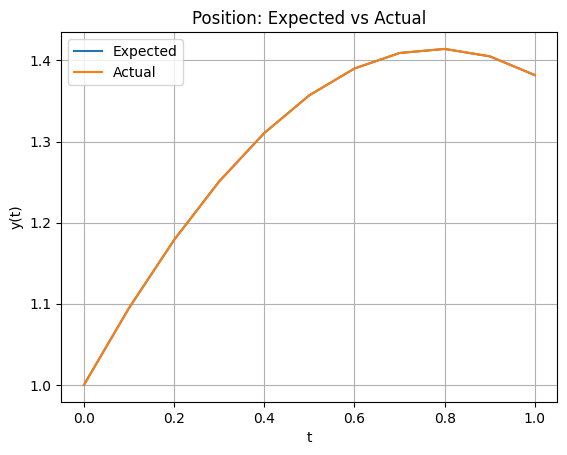

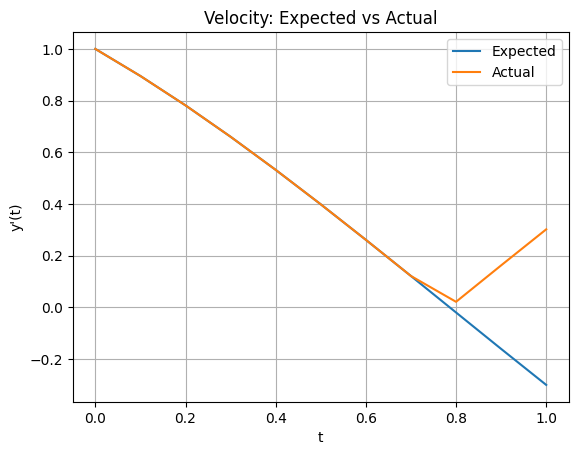

In [67]:
import matplotlib.pyplot as plt

# --- y(t) ---
plt.figure()
plt.plot(time_range, y_values)
plt.plot(time_range, y)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Position: Expected vs Actual")
plt.legend(["Expected", "Actual"])
plt.grid(True)
plt.show()


# --- y'(t) ---
plt.figure()
plt.plot(time_range, y_dash_values)
plt.plot(time_range, y_dash)
plt.xlabel("t")
plt.ylabel("y'(t)")
plt.title("Velocity: Expected vs Actual")
plt.legend(["Expected", "Actual"])
plt.grid(True)
plt.show()

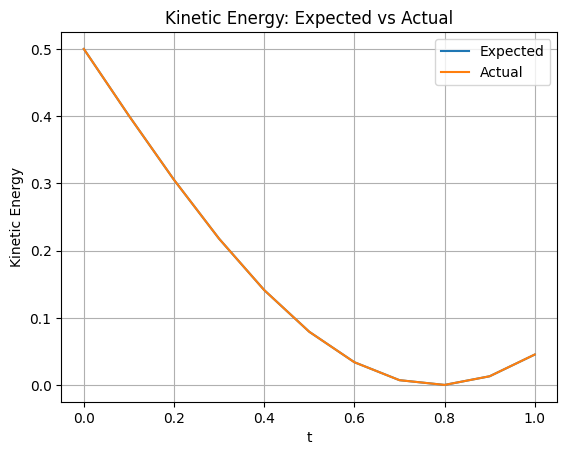

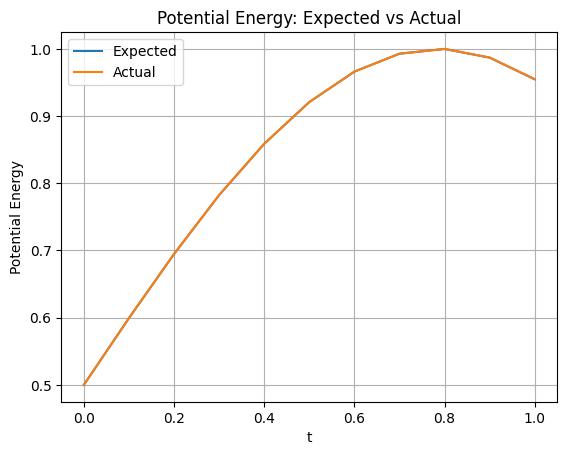

In [68]:
# --- Kinetic Energy ---
plt.figure()
plt.plot(time_range, kinetic_expected)
plt.plot(time_range, kinetic_actual)
plt.xlabel("t")
plt.ylabel("Kinetic Energy")
plt.title("Kinetic Energy: Expected vs Actual")
plt.legend(["Expected", "Actual"])
plt.grid(True)
plt.show()


# --- Potential Energy ---
plt.figure()
plt.plot(time_range, potential_expected)
plt.plot(time_range, potential_actual)
plt.xlabel("t")
plt.ylabel("Potential Energy")
plt.title("Potential Energy: Expected vs Actual")
plt.legend(["Expected", "Actual"])
plt.grid(True)
plt.show()

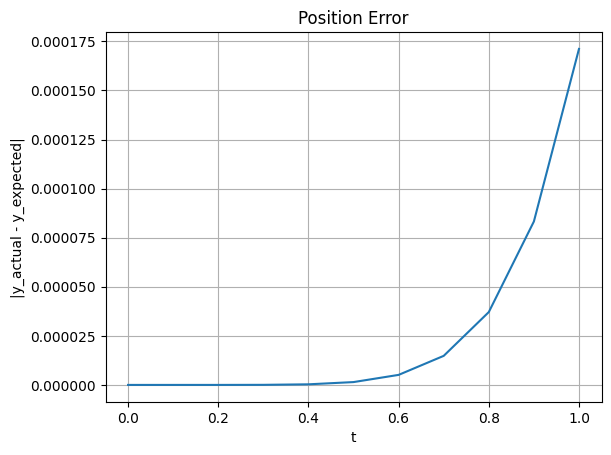

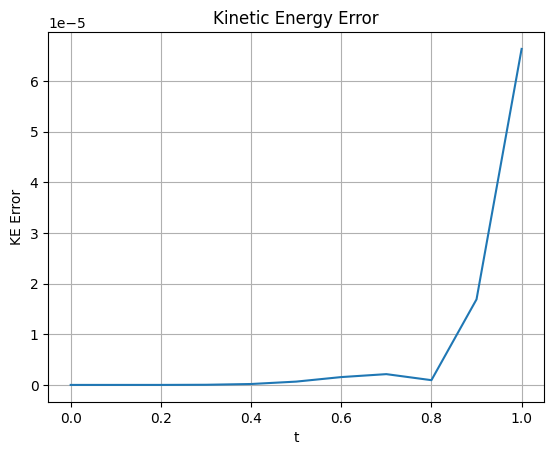

In [69]:
position_error = np.abs(y - y_values)
velocity_error = np.abs(y_dash - y_dash_values)
ke_error = np.abs(kinetic_actual - kinetic_expected)
pe_error = np.abs(potential_actual - potential_expected)

plt.figure()
plt.plot(time_range, position_error)
plt.xlabel("t")
plt.ylabel("|y_actual - y_expected|")
plt.title("Position Error")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time_range, ke_error)
plt.xlabel("t")
plt.ylabel("KE Error")
plt.title("Kinetic Energy Error")
plt.grid(True)
plt.show()